In [4]:
# -*- coding: utf-8 -*-
"""
Created on Sat Aug  6 12:53:41 2022

@author: Amin
"""
# %%
import sys
sys.path.insert(1,'../')

from jax import vmap
import jax.numpy as jnp
import jax.random as jxr

import models
import inference
import visualizations
import simulations
import utils
import params

%load_ext autoreload
%autoreload 2

In [5]:
# %% load data
save=False
file='../results/motor_nonlinear/'

T = 10
dt = .05
K = 10
N = 2 # Observation dimension (must be >= D for InjectiveFlowEmission)
D = 2 # Latent dimension

In [ ]:
# Run simulation
seed = 10
key = jxr.PRNGKey(seed)

k1, key = jxr.split(key,2)
u = []
for i in range(K):
    u_,_ = utils.stimulation_protocol(
        k1,
        time_st=0,
        time_en=T,
        dt=dt,
        N=N,
        stimulated=jnp.arange(N),
        amplitude=1*jnp.ones(N),
        stim_d=1.,
        rest_d=1.,
        repetition=15,
        sigma=.5
    )
    u.append(u_)

u = jnp.array(u)

In [ ]:
# %% Generate dataset using Rotational Dynamics mapped to higher dims
k1, key = jxr.split(key,2)

# We use a projection matrix C to map the 2D dynamics into a 2D observation space
# C = jxr.orthogonal(k1, n=N)[:D,:] 
# p = {'a':1.2, 'sigma':0., 'D':2, 'C': C}
# system = networks.RotationalDynamics(p,discrete=True)
# t,x_ = system.run(
#     T,dt=dt,u=u,
#     x0=1*jxr.normal(k1,shape=(K,p['D']))
# )
# y_ = system.obs(x_)
# y_ += 0.05*jxr.normal(k1,shape=y_.shape) # Add slight observation noise

# p = {'a1':-20, 'a2': 1.2, 'sigma':1.1,'N':2}
p = {'a1':-20, 'a2': 1.2, 'sigma':0.,'D':2}
system = simulations.DynamicAttractor(p,discrete=True)

t,x_ = system.run(
    T,dt=dt,u=u,
    x0=1*jxr.normal(k1,shape=(K,p['D']))
)
y_ = system.obs(x_)


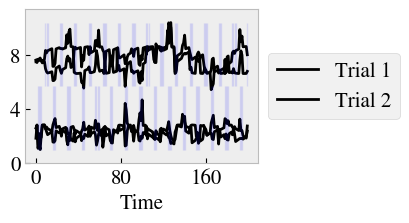

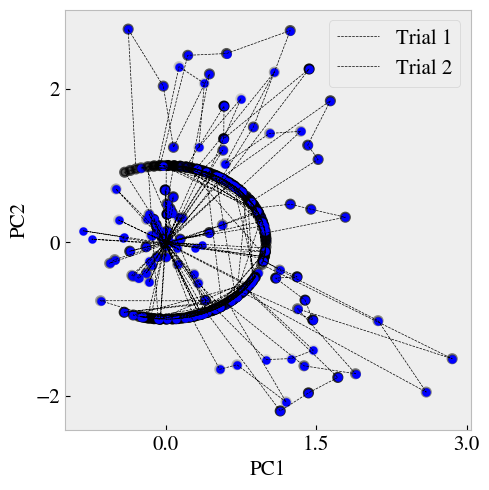

In [8]:

# %%
y = y_.transpose(1,0,2)
x = x_.transpose(1,0,2)
    
visualizations.plot_signals(
    y[:2],inp=u[0],labels=['Trial 1', 'Trial 2'],
    save=save,file=file+'signals'
)
visualizations.plot_states(
    y[:2, :, :2],input=u[0],labels=['Trial 1', 'Trial 2'], # Plot first two dims
    save=save,file=file+'states'
)



In [10]:
# %% 
k1,k2,k3,key = jxr.split(key,4)

initial_params = params.ParamsNormal(
    mu = jnp.zeros(D),
    scale_tril = dt*jnp.eye(D)
)

# Use new MLPDynamics Parameters
dyn_params = params.ParamsMLPDynamics(
    scale_tril = dt*jnp.eye(D),
    mlp_params = None,
    B = jnp.eye(D, N), # M=N for inputs
    initial = initial_params
)

likelihood_params = params.ParamsConditionalNormal(
    scale_tril = dt*jnp.eye(N)
)

interventional=True
initial = models.InitialCondition(D, initial_params)

# Initialize the new AnalyticMLPDynamics and InjectiveFlowEmission models
dynamics = models.AnalyticMLPDynamics(
    D=D,M=N,initial=initial,params=dyn_params,dt=dt,
    train_B=True,interventional=interventional,
    hidden_dim=2, num_hidden_layers=2, activation='gelu',
    init_scale=0.01, key=k1
)
emission = models.InjectiveFlowEmission(
    D=D,N=N,key=k2,H=64,num_layers_g1=3,num_layers_g2=3
)
# emission = models.NeuralNetEmission(D,N,key=k2,H=100)

likelihood = models.NormalConditionalLikelihood(N,params=likelihood_params)
joint = models.fLDS(dynamics,emission,likelihood)

recognition = inference.AmortizedLSTM(
    D=D,N=N,M=N,key=k3,T=y.shape[1],interventional=interventional
)


In [11]:

# %% Inference
k1, key = jxr.split(key,2)

loss = inference.infer(
    k1,joint,recognition,y,u,
    n_iter=1000,step_size=5e-2,
    gamma=1.
)


  0%|          | 0/1000 [00:00<?, ?it/s]

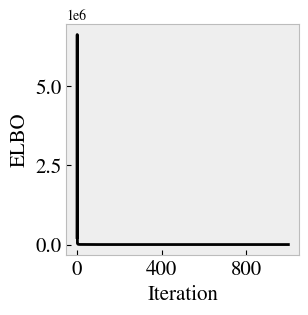

In [ ]:
# %% Visualization
visualizations.plot_loss(loss,ylabel='ELBO',save=save,file=file+'loss')

In [13]:
# %%
k1, k2, key = jxr.split(key,3)

x_smooth = vmap(
    lambda y,u: recognition(recognition.params,k1,y,u)[0],
    in_axes=(0,0),out_axes=0
)(y,u)

mean = vmap(
    lambda x: emission(emission.params,x),
    in_axes=(0),out_axes=0
)(x_smooth)

y_smooth = vmap(
    lambda mu: likelihood.sample(likelihood_params,mu,key=k2),
    in_axes=(0),out_axes=0
)(mean)


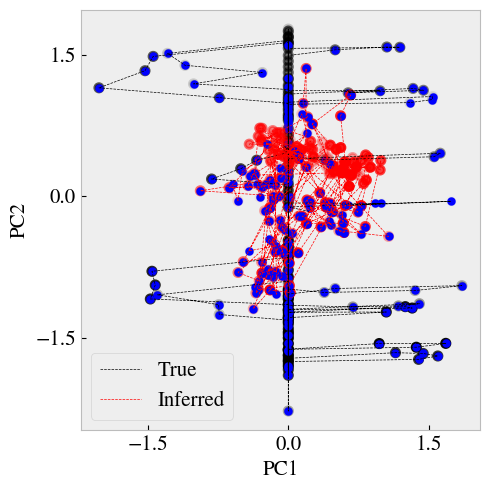

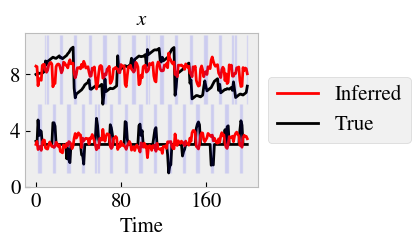

In [14]:
i=1

visualizations.plot_states(
    [x_[:,i],x_smooth[i]],
    input=u[i],colors=['k','r'],
    labels=['True','Inferred'],
    save=save,file=file+'states_x_inferred'
)

visualizations.plot_signals(
    [x_[:,i],x_smooth[i]],inp=u[i],
    colors=['k','r'],titlestr='$x$',labels=['True','Inferred'],
    save=save,file=file+'signals_x_inferred'
)

In [15]:
# %% Correlations
print('x-corr: ', jnp.corrcoef(x[u==0].flatten(),x_smooth[u==0].flatten())[0,1])
print('y-corr: ', jnp.corrcoef(y[u == 0].flatten(),y_smooth[u == 0].flatten())[0,1])

x-corr:  0.18389496
y-corr:  0.71352375


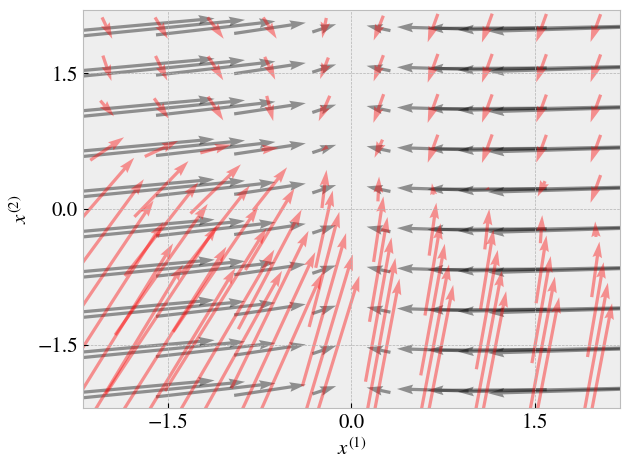

In [16]:
# %% Flow comparisons
true_flow_x = lambda x_val: system.step(0, x_val)
inferred_flow_x = lambda x_val: dynamics._drift(dynamics.params, x_val)

visualizations.flow_2d(
    [true_flow_x, inferred_flow_x],
    colors=[[0,0,0,.4], [1,0,0,.4]],
    scale=1e-2,
    xlim=[-2,2],
    ylim=[-2,2],
    n_points=10,
    show=False,
    save=save,
    file=file+'inferred_flow'
)